# FLAML AutoML

Проверяю AutoML-бейзлайн на всех подготовленных наборах признаков и той же валидационной части. Бюджет ограничен явно через `time_budget`, чтобы эксперимент был сопоставим по времени с остальными моделями.

> Используйте python3.12 в окружении, на 3.14 есть некая несовместимость

In [1]:
from pathlib import Path

import gc
import os
import random
import pickle
import warnings

for warn in [FutureWarning, UserWarning]:
    warnings.filterwarnings("ignore", category=warn)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from flaml.automl.automl import AutoML

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve

In [2]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

## Настройка путей и логирования

In [3]:
PROJECT_DIR = Path("/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton")
DATA_DIR = PROJECT_DIR / "data"
BASE_DIR = DATA_DIR

LOGS_DIR = PROJECT_DIR / "logs" / "flaml_automl_log"
MODELS_DIR = PROJECT_DIR / "models" / "flaml_automl_models"
SUBMISSIONS_DIR = PROJECT_DIR / "submissions"

LOGS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    BASE_DIR / "y_train_sampled.parquet",
    BASE_DIR / "y_train_full.parquet",
    BASE_DIR / "y_val.parquet",
]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Не нашел подготовленные parquet-файлы:\n"
        + "\n".join(str(path) for path in missing_files)
    )

print("PROJECT_DIR:", PROJECT_DIR)
print("BASE_DIR:", BASE_DIR)
print("LOGS_DIR:", LOGS_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("SUBMISSIONS_DIR:", SUBMISSIONS_DIR)

PROJECT_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton
BASE_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data
LOGS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/logs/flaml_automl_log
MODELS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_models
SUBMISSIONS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/submissions


## Загрузка данных

In [4]:
# Проверяю все feature set-ы из основного пайплайна.
feature_sets = [
    "top300",
    "top500_clean",
    "top500_lgb_clean",
    "top500_magic_meta",
    "top500_micro_engineered",
]


def resolve_feature_path(folder, split):
    file_name = f"X_{split}_{folder}.parquet"
    candidates = [
        BASE_DIR / folder / file_name,
        BASE_DIR / file_name,
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Не нашел файл с признаками. Проверенные пути:\n"
        + "\n".join(str(path) for path in candidates)
    )


def read_feature_matrix(folder, split):
    path = resolve_feature_path(folder, split)
    print(f"read {split:<13} {folder:<25} -> {path}")
    return pd.read_parquet(path)


def read_target(name):
    path = BASE_DIR / f"y_{name}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Не нашел target-файл: {path}")

    return pd.read_parquet(path).iloc[:, 0].values.ravel()


missing_paths = []
for folder in feature_sets:
    for split in ["train_sampled", "train_full", "val", "test"]:
        try:
            resolve_feature_path(folder, split)
        except FileNotFoundError as error:
            missing_paths.append(str(error))

if missing_paths:
    raise FileNotFoundError("Не хватает файлов для запуска:\n\n" + "\n\n".join(missing_paths))

print("feature sets:", feature_sets)

feature sets: ['top300', 'top500_clean', 'top500_lgb_clean', 'top500_magic_meta', 'top500_micro_engineered']


## Метрики и подбор порога

In [5]:
def count_metrics(y_true, y_pred, y_score):
    """
    roc_auc_score: вероятность того, что модель присвоит случайному объекту класса 1 более высокий score, чем случайному объекту класса 0; чем ближе к 1, тем лучше разделение классов, 0.5 — уровень случайного угадывания.

    average_precision_score: среднее качество поиска объектов класса 1 по всем возможным порогам; высокая метрика означает, что среди объектов, которые модель считает наиболее похожими на класс 1, действительно много единиц.

    balanced_accuracy_score: средняя точность отдельно по классу 0 и по классу 1; полезна при дисбалансе классов, потому что не дает модели выглядеть хорошей только за счет угадывания самого частого класса.

    f1_score: одна итоговая оценка качества предсказания класса 1, которая будет высокой только тогда, когда модель одновременно находит много настоящих единиц и не слишком часто ошибочно объявляет нули единицами.
    """

    print("roc auc:", roc_auc_score(y_true, y_score))
    print("average precision:", average_precision_score(y_true, y_score))
    print("balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("f1:", f1_score(y_true, y_pred, zero_division=0))


def best_f1_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1_values = 2 * precision * recall / (precision + recall + 1e-12)

    best_idx = int(np.nanargmax(f1_values[:-1]))
    return float(thresholds[best_idx])


def predict_with_threshold(y_score, threshold):
    return (y_score >= threshold).astype(int)


def positive_class_score(model, X):
    proba = model.predict_proba(X)
    proba = np.asarray(proba)

    if proba.ndim == 1:
        return proba

    if proba.shape[1] == 1:
        return proba[:, 0]

    return proba[:, 1]

## Настройка FLAML

In [6]:
# Бюджет задается на один feature set и один запуск FLAML.
TIME_BUDGET_SAMPLED = 1250  # тут ну просто слегка побольше предыдущего запуска
TIME_BUDGET_FULL = 5750  # ставлю все на full обучение

BASE_ESTIMATORS = ["lgbm", "rf", "extra_tree"]

try:
    import catboost  # noqa: F401
    BASE_ESTIMATORS.append("catboost")
except Exception:
    pass

print("estimators:", BASE_ESTIMATORS)
print(
    "max search budget, hours:",
    round(len(feature_sets) * (TIME_BUDGET_SAMPLED + TIME_BUDGET_FULL) / 3600, 2),
)


def make_automl_settings(folder, train_mode, time_budget):
    log_file_path = LOGS_DIR / f"{folder}_{train_mode}.log"
    if log_file_path.exists():
        log_file_path.unlink()

    return {
        "time_budget": time_budget,
        "metric": "roc_auc",
        "task": "classification",
        "estimator_list": BASE_ESTIMATORS,
        "eval_method": "holdout",
        "n_jobs": -1,
        "seed": SEED,
        "verbose": 1,
        "log_file_name": str(log_file_path),
        "log_type": "all",
        "keep_search_state": True,
    }


def fit_flaml(X_train, y_train, X_val, y_val, folder, train_mode, time_budget):
    automl = AutoML()
    settings = make_automl_settings(folder, train_mode, time_budget)

    automl.fit(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        **settings,
    )

    return automl

estimators: ['lgbm', 'rf', 'extra_tree', 'catboost']
max search budget, hours: 9.72


## Поиск на усеченной обучающей выборке

In [7]:
y_train_sampled = read_target("train_sampled")
y_val = read_target("val")

sampled_rows = []

In [8]:
for folder in feature_sets:
    print("\n" + "=" * 56)
    print(f"FLAML SAMPLED: {folder}")
    print("=" * 56)

    X_train_sampled = read_feature_matrix(folder, "train_sampled")
    X_val = read_feature_matrix(folder, "val")

    assert len(X_train_sampled) == len(y_train_sampled)
    assert len(X_val) == len(y_val)

    try:
        automl = fit_flaml(
            X_train_sampled,
            y_train_sampled,
            X_val,
            y_val,
            folder=folder,
            train_mode="sampled",
            time_budget=TIME_BUDGET_SAMPLED,
        )

        y_score = positive_class_score(automl, X_val)
        roc_auc = roc_auc_score(y_val, y_score)

        sampled_rows.append(
            {
                "feature_set": folder,
                "best_roc_auc": roc_auc,
                "best_estimator": automl.best_estimator,
                "best_config": automl.best_config,
                "time_budget": TIME_BUDGET_SAMPLED,
            }
        )

        print("best estimator:", automl.best_estimator)
        print("best config:", automl.best_config)
        print("val roc auc:", roc_auc)

    except Exception as error:
        sampled_rows.append(
            {
                "feature_set": folder,
                "best_roc_auc": np.nan,
                "best_estimator": None,
                "best_config": None,
                "time_budget": TIME_BUDGET_SAMPLED,
                "error": repr(error),
            }
        )
        print(f"ОШИБКА НА {folder}: {error}")

    finally:
        del X_train_sampled, X_val
        if "automl" in locals():
            del automl
        gc.collect()


FLAML SAMPLED: top300
read train_sampled top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_train_sampled_top300.parquet
read val           top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_val_top300.parquet
best estimator: lgbm
best config: {'n_estimators': 555, 'num_leaves': 88, 'min_child_samples': 100, 'learning_rate': np.float64(0.03359846257622969), 'log_max_bin': 10, 'colsample_bytree': np.float64(0.5812912884295434), 'reg_alpha': np.float64(21.816095707712133), 'reg_lambda': np.float64(0.2207925240288567)}
val roc auc: 0.6577274321789283

FLAML SAMPLED: top500_clean
read train_sampled top500_clean              -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top500_clean/X_train_sampled_top500_clean.parquet
read val           top500_clean              -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top500_clean/X_val_t

In [9]:
sampled_results_df = pd.DataFrame(sampled_rows).sort_values(
    "best_roc_auc", ascending=False, na_position="last"
).reset_index(drop=True)

sampled_results_df

,feature_set,best_roc_auc,best_estimator,best_config,time_budget
0,top500_magic_meta,0.664637,lgbm,"{'n_estimators': 1139, 'num_leaves': 40, 'min_...",1250
1,top500_micro_engineered,0.661048,lgbm,"{'n_estimators': 1139, 'num_leaves': 40, 'min_...",1250
2,top500_lgb_clean,0.659060,lgbm,"{'n_estimators': 1194, 'num_leaves': 177, 'min...",1250
3,top300,0.657727,lgbm,"{'n_estimators': 555, 'num_leaves': 88, 'min_c...",1250
4,top500_clean,0.656317,rf,"{'n_estimators': 853, 'max_features': 0.107064...",1250


## Поиск на полной обучающей выборке

In [10]:
y_train_full = read_target("train_full")
y_val = read_target("val")

full_rows = []
saved_model_paths = {}
final_thresholds = {}

In [11]:
for folder in feature_sets:
    print("\n" + "=" * 56)
    print(f"FLAML FULL: {folder}")
    print("=" * 56)

    X_train_full = read_feature_matrix(folder, "train_full")
    X_val = read_feature_matrix(folder, "val")

    assert len(X_train_full) == len(y_train_full)
    assert len(X_val) == len(y_val)

    try:
        automl = fit_flaml(
            X_train_full,
            y_train_full,
            X_val,
            y_val,
            folder=folder,
            train_mode="full",
            time_budget=TIME_BUDGET_FULL,
        )

        y_score_train = positive_class_score(automl, X_train_full)
        threshold = best_f1_threshold(y_train_full, y_score_train)

        y_score_val = positive_class_score(automl, X_val)
        y_pred_val = predict_with_threshold(y_score_val, threshold)

        roc_auc = roc_auc_score(y_val, y_score_val)
        avg_precision = average_precision_score(y_val, y_score_val)
        balanced_acc = balanced_accuracy_score(y_val, y_pred_val)
        f1 = f1_score(y_val, y_pred_val, zero_division=0)

        model_path = MODELS_DIR / f"flaml_{folder}_{roc_auc:.5f}.pkl"
        with open(model_path, "wb") as f:
            pickle.dump(automl, f)

        saved_model_paths[folder] = model_path
        final_thresholds[folder] = threshold

        full_rows.append(
            {
                "feature_set": folder,
                "roc_auc": roc_auc,
                "average_precision": avg_precision,
                "balanced_accuracy": balanced_acc,
                "f1": f1,
                "threshold": threshold,
                "best_estimator": automl.best_estimator,
                "best_config": automl.best_config,
                "model_path": str(model_path),
            }
        )

        print("best estimator:", automl.best_estimator)
        print("best config:", automl.best_config)
        print("saved model:", model_path)
        print("threshold:", threshold)
        count_metrics(y_val, y_pred_val, y_score_val)

    except Exception as error:
        full_rows.append(
            {
                "feature_set": folder,
                "roc_auc": np.nan,
                "average_precision": np.nan,
                "balanced_accuracy": np.nan,
                "f1": np.nan,
                "threshold": np.nan,
                "best_estimator": None,
                "best_config": None,
                "model_path": None,
                "error": repr(error),
            }
        )
        print(f"ОШИБКА НА {folder}: {error}")

    finally:
        del X_train_full, X_val
        if "automl" in locals():
            del automl
        if "y_score_train" in locals():
            del y_score_train
        if "y_score_val" in locals():
            del y_score_val
        if "y_pred_val" in locals():
            del y_pred_val
        gc.collect()


FLAML FULL: top300
read train_full    top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_train_full_top300.parquet
read val           top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_val_top300.parquet
best estimator: rf
best config: {'n_estimators': 872, 'max_features': np.float64(0.31953620059356086), 'max_leaves': 373, 'criterion': np.str_('entropy')}
saved model: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_models/flaml_top300_0.65183.pkl
threshold: 0.04348006922048869
roc auc: 0.6518293207147832
average precision: 0.09232135223971574
balanced accuracy: 0.5450603782399911
f1: 0.14485981308411214

FLAML FULL: top500_clean
read train_full    top500_clean              -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top500_clean/X_train_full_top500_clean.parquet
read val           top500_clean              -> /

## Сравнение финальных моделей

In [12]:
final_results_df = pd.DataFrame(full_rows).sort_values(
    "roc_auc", ascending=False, na_position="last"
).reset_index(drop=True)

if final_results_df["roc_auc"].notna().sum() == 0:
    raise RuntimeError("FLAML не обучил ни одной успешной модели. См. колонку error в final_results_df.")

final_results_df.style.format(
    {
        "roc_auc": "{:.6f}",
        "average_precision": "{:.6f}",
        "balanced_accuracy": "{:.6f}",
        "f1": "{:.6f}",
        "threshold": "{:.6f}",
    }
)

,feature_set,roc_auc,average_precision,balanced_accuracy,f1,threshold,best_estimator,best_config,model_path
0,top500_magic_meta,0.663771,0.069674,0.534250,0.109589,0.063190,lgbm,"{'n_estimators': 2212, 'num_leaves': 58, 'min_child_samples': 128, 'learning_rate': np.float64(0.010754331144599436), 'log_max_bin': 9, 'colsample_bytree': np.float64(0.5451462522227247), 'reg_alpha': np.float64(0.014693474164992832), 'reg_lambda': np.float64(107.00615177567863)}",/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_models/flaml_top500_magic_meta_0.66377.pkl
1,top500_clean,0.662123,0.056661,0.530933,0.097345,0.065355,lgbm,"{'n_estimators': 2177, 'num_leaves': 86, 'min_child_samples': 13, 'learning_rate': np.float64(0.029765214319871412), 'log_max_bin': 9, 'colsample_bytree': np.float64(0.561305918587751), 'reg_alpha': np.float64(0.22221368520987675), 'reg_lambda': np.float64(899.7005650241036)}",/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_models/flaml_top500_clean_0.66212.pkl
2,top500_micro_engineered,0.661218,0.057210,0.531639,0.099010,0.065962,lgbm,"{'n_estimators': 5310, 'num_leaves': 184, 'min_child_samples': 17, 'learning_rate': np.float64(0.015026651970545072), 'log_max_bin': 10, 'colsample_bytree': np.float64(0.3577655765625633), 'reg_alpha': np.float64(24.45511059748249), 'reg_lambda': np.float64(0.6243415282314914)}",/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_models/flaml_top500_micro_engineered_0.66122.pkl
3,top500_lgb_clean,0.657992,0.057355,0.526294,0.088200,0.064486,lgbm,"{'n_estimators': 1037, 'num_leaves': 27, 'min_child_samples': 27, 'learning_rate': np.float64(0.0168480461284172), 'log_max_bin': 9, 'colsample_bytree': np.float64(0.9234507685867764), 'reg_alpha': np.float64(0.0013692982135039818), 'reg_lambda': np.float64(6.46993906886223)}",/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_models/flaml_top500_lgb_clean_0.65799.pkl
4,top300,0.651829,0.092321,0.545060,0.144860,0.043480,rf,"{'n_estimators': 872, 'max_features': np.float64(0.31953620059356086), 'max_leaves': 373, 'criterion': np.str_('entropy')}",/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_models/flaml_top300_0.65183.pkl


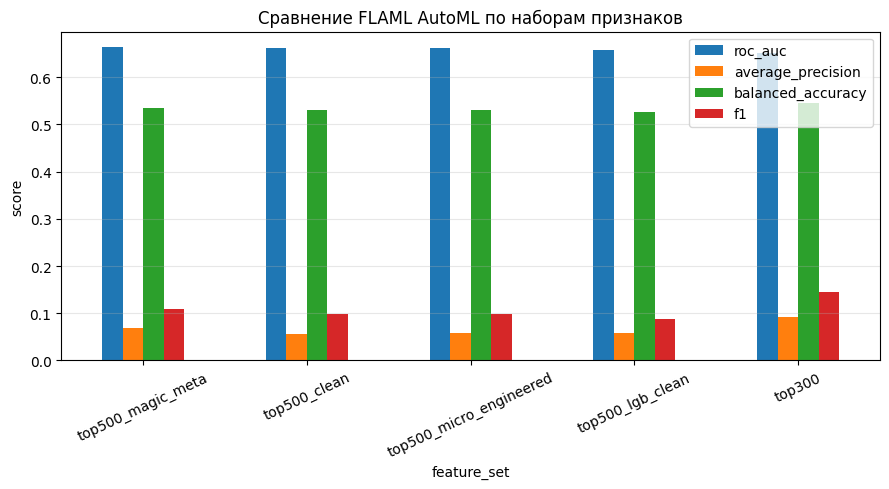

In [13]:
metrics_to_plot = ["roc_auc", "average_precision", "balanced_accuracy", "f1"]

final_results_df.dropna(subset=["roc_auc"]).set_index("feature_set")[metrics_to_plot].plot(
    kind="bar", figsize=(9, 5), rot=25, title="Сравнение FLAML AutoML по наборам признаков"
)

plt.ylabel("score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
best_folder = final_results_df.loc[0, "feature_set"]
best_model_path = Path(final_results_df.loc[0, "model_path"])

print("best feature set:", best_folder)
print("best model:", best_model_path)
print("best val roc auc:", final_results_df.loc[0, "roc_auc"])
print("best threshold:", final_results_df.loc[0, "threshold"])
print("best estimator:", final_results_df.loc[0, "best_estimator"])

best feature set: top500_magic_meta
best model: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/flaml_automl_models/flaml_top500_magic_meta_0.66377.pkl
best val roc auc: 0.6637707401929164
best threshold: 0.06319035764070675
best estimator: lgbm


## Confusion matrix для лучшей модели

read val           top500_magic_meta         -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top500_magic_meta/X_val_top500_magic_meta.parquet


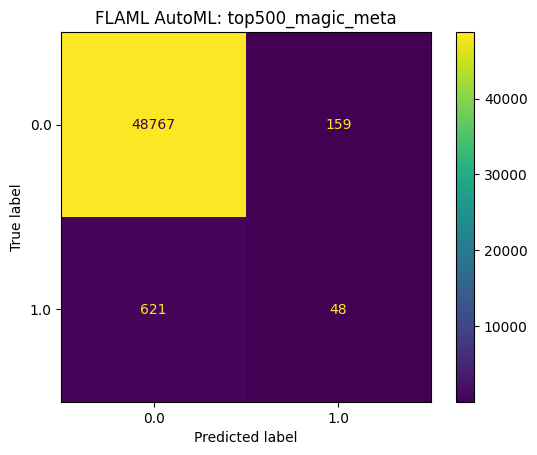

roc auc: 0.6637707401929164
average precision: 0.06967355154587399
balanced accuracy: 0.5342495365472777
f1: 0.1095890410958904


4196

In [15]:
with open(best_model_path, "rb") as f:
    best_model = pickle.load(f)

X_val_best = read_feature_matrix(best_folder, "val")
y_score_best = positive_class_score(best_model, X_val_best)
y_pred_best = predict_with_threshold(
    y_score_best, final_thresholds.get(best_folder, final_results_df.loc[0, "threshold"])
)

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_best)
plt.title(f"FLAML AutoML: {best_folder}")
plt.show()

count_metrics(y_val, y_pred_best, y_score_best)

del X_val_best, best_model, y_score_best, y_pred_best
gc.collect()

## Предсказание для test и сабмит

Финальный `.csv` пишется по лучшей модели. Если в проекте уже есть `sample_submission.csv` или `submit.csv`, используем его как шаблон; иначе создаем таблицу с индексом из `X_test`.

In [16]:
RUN_SUBMISSION = True

if RUN_SUBMISSION:
    with open(best_model_path, "rb") as f:
        best_model = pickle.load(f)

    X_test = read_feature_matrix(best_folder, "test")
    test_score = positive_class_score(best_model, X_test)

    submit_candidates = [
        DATA_DIR / "sample_submission.csv",
        DATA_DIR / "submit.csv",
        PROJECT_DIR / "sample_submission.csv",
        PROJECT_DIR / "submit.csv",
    ]
    submit_path = next((path for path in submit_candidates if path.exists()), None)

    if submit_path is not None:
        submission = pd.read_csv(submit_path)
        target_col = "target" if "target" in submission.columns else submission.columns[-1]
        submission[target_col] = test_score
    else:
        submission = pd.DataFrame(
            {
                "index": X_test.index,
                "target": test_score,
            }
        )

    submission_path = SUBMISSIONS_DIR / f"flaml_{best_folder}_{final_results_df.loc[0, 'roc_auc']:.5f}.csv"
    submission.to_csv(submission_path, index=False)

    print("submission saved:", submission_path)
    display(submission.head())

    del X_test, best_model, test_score, submission
    gc.collect()

read test          top500_magic_meta         -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top500_magic_meta/X_test_top500_magic_meta.parquet
submission saved: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/submissions/flaml_top500_magic_meta_0.66377.csv


,index,score
0,194357,0.002652
1,313222,0.014732
2,321873,0.022363
3,118689,0.009188
4,342561,0.004314


## Сохранение таблиц с результатами

In [17]:
sampled_results_path = LOGS_DIR / "sampled_results.csv"
final_results_path = LOGS_DIR / "final_results.csv"

sampled_results_df.to_csv(sampled_results_path, index=False)
final_results_df.to_csv(final_results_path, index=False)

print("sampled results saved:", sampled_results_path)
print("final results saved:", final_results_path)

sampled results saved: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/logs/flaml_automl_log/sampled_results.csv
final results saved: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/logs/flaml_automl_log/final_results.csv
